# Bank Loan Risk Analytics - EDA

## Basic Initial Analysis of the Data

In [2]:
# importing required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# reading the 'loan' dataset into a dataframe, and checking the first 5 rows

loan_df = pd.read_csv('loan.csv')
loan_df.head()

C:\Users\sindh\AppData\Local\Temp\ipykernel_40396\1236394068.py:3: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  loan_df = pd.read_csv(r'C:\Users\sindh\OneDrive\Desktop\UPGRAD\Python PRACTICE\loan\loan.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [4]:
pd.set_option('display.max_rows', None)  # to show all rows
pd.set_option('display.max_columns', None) # to show all columns

In [5]:
# finding the no. of rows and columns of the dataset

loan_df.shape

(39717, 111)

#### We see that there are a total of 111 columns and 39717 rows in the dataset

In [6]:
# understanding the columns & their datatypes

loan_df.info(max_cols=150) # max_cols argument is for displaying all the columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 111 columns):
 #    Column                          Non-Null Count  Dtype  
---   ------                          --------------  -----  
 0    id                              39717 non-null  int64  
 1    member_id                       39717 non-null  int64  
 2    loan_amnt                       39717 non-null  int64  
 3    funded_amnt                     39717 non-null  int64  
 4    funded_amnt_inv                 39717 non-null  float64
 5    term                            39717 non-null  object 
 6    int_rate                        39717 non-null  object 
 7    installment                     39717 non-null  float64
 8    grade                           39717 non-null  object 
 9    sub_grade                       39717 non-null  object 
 10   emp_title                       37258 non-null  object 
 11   emp_length                      38642 non-null  object 
 12   home_ownership  

In [7]:
#statistical summary of the dataset

loan_df.describe(include='all')

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
count,3.971700e+04,3.971700e+04,39717.000000,39717.000000,39717.000000,39717,39717,39717.000000,39717,39717,37258,38642,39717,3.971700e+04,39717,39717,39717,39717,39717,26775,39717,39706,39717,39717,39717.000000,39717.000000,39717,39717.000000,14035.000000,2786.000000,39717.000000,39717.000000,39717.000000,39667,39717.000000,39717,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39646,39717.000000,1140,39715,39661.0,0.0,39717.0,39717,0.0,0.0,0.0,39717.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39661.0,39717.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39020.000000,39678.0,0.0,0.0,0.0,0.0
unique,NaN,NaN,NaN,NaN,NaN,2,371,NaN,7,35,28820,11,5,NaN,3,55,3,1,39717,26526,14,19615,823,50,NaN,NaN,526,NaN,NaN,NaN,NaN,NaN,NaN,1089,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101,NaN,2,106,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,36 months,10.99%,NaN,B,B3,US Army,10+ years,RENT,NaN,Not Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,,debt_consolidation,Debt Consolidation,100xx,CA,NaN,NaN,Nov-98,NaN,NaN,NaN,NaN,NaN,NaN,0%,NaN,f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May-16,NaN,Jun-16,May-16,NaN,NaN,NaN,INDIVIDUAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,29096,956,NaN,12020,2917,134,8879,18899,NaN,16921,2260,32950,39717,1,210,18641,2184,597,7099,NaN,NaN,370,NaN,NaN,NaN,NaN,NaN,NaN,977,NaN,39717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1256,NaN,1125,10308,NaN,NaN,NaN,39717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,6.831319e+05,8.504636e+05,11219.443815,10947.713196,10397.448868,NaN,NaN,324.561922,NaN,NaN,NaN,NaN,NaN,6.896893e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.315130,0.14

## Handling Missing Values

### After performing basic analyis of the dataset, let's check for any missing values

In [8]:
# finding the count of null values in each column

loan_df.isnull().sum()

id                                    0
member_id                             0
loan_amnt                             0
funded_amnt                           0
funded_amnt_inv                       0
term                                  0
int_rate                              0
installment                           0
grade                                 0
sub_grade                             0
emp_title                          2459
emp_length                         1075
home_ownership                        0
annual_inc                            0
verification_status                   0
issue_d                               0
loan_status                           0
pymnt_plan                            0
url                                   0
desc                              12942
purpose                               0
title                                11
zip_code                              0
addr_state                            0
dti                                   0


In [9]:
# since count won't give us a clear picture, let's check the percentage of null values in each column, rounded off to 2 decimals

round( (loan_df.isnull().sum() / len(loan_df.index) )*100, 2 )

id                                  0.00
member_id                           0.00
loan_amnt                           0.00
funded_amnt                         0.00
funded_amnt_inv                     0.00
term                                0.00
int_rate                            0.00
installment                         0.00
grade                               0.00
sub_grade                           0.00
emp_title                           6.19
emp_length                          2.71
home_ownership                      0.00
annual_inc                          0.00
verification_status                 0.00
issue_d                             0.00
loan_status                         0.00
pymnt_plan                          0.00
url                                 0.00
desc                               32.59
purpose                             0.00
title                               0.03
zip_code                            0.00
addr_state                          0.00
dti             

#### It is clear that there are many columns with all null values, in other words, empty columns. 
#### Since imputation is not possible and also doesn't make any sense, it is best to delete them from the dataframe.

In [10]:
# deleting all the completely NULL columns

loan_df = loan_df.dropna(axis=1, how='all')
loan_df.shape

(39717, 57)

In [11]:
# similarly, deleting all rows which are completely NULL, if any

loan_df = loan_df.dropna(axis=0, how='all')
loan_df.shape

(39717, 57)

In [12]:
# rechecking the percentage of NULL values in each column

round( (loan_df.isnull().sum() / len(loan_df.index) )*100, 2 )

id                             0.00
member_id                      0.00
loan_amnt                      0.00
funded_amnt                    0.00
funded_amnt_inv                0.00
term                           0.00
int_rate                       0.00
installment                    0.00
grade                          0.00
sub_grade                      0.00
emp_title                      6.19
emp_length                     2.71
home_ownership                 0.00
annual_inc                     0.00
verification_status            0.00
issue_d                        0.00
loan_status                    0.00
pymnt_plan                     0.00
url                            0.00
desc                          32.59
purpose                        0.00
title                          0.03
zip_code                       0.00
addr_state                     0.00
dti                            0.00
delinq_2yrs                    0.00
earliest_cr_line               0.00
inq_last_6mths              

#### Let's drop some more columns that are unnecessary for our analysis purpose.

In [13]:
# dropping columns unnecessary for analysis

loan_df = loan_df.drop(columns=['application_type', 'pymnt_plan', 'desc', 'url', 'zip_code', 'mths_since_last_record', 'next_pymnt_d'])

In [14]:
# dropping columns unnecessary for analysis

loan_df = loan_df.drop(columns=['grade', 'initial_list_status', 'id', 'collections_12_mths_ex_med', 'chargeoff_within_12_mths', 'delinq_amnt', 'tax_liens'])

In [15]:
# rechecking the shape after deleting unnecessary & null/all-zero columns

loan_df.shape

(39717, 43)

#### The dataframe has now been reduced to 43 columns (from 111 columns) after dropping all unnecessary and null columns.

In [16]:
# rechecking null value %

round( (loan_df.isnull().sum() / len(loan_df.index) )*100, 2 )

member_id                   0.00
loan_amnt                   0.00
funded_amnt                 0.00
funded_amnt_inv             0.00
term                        0.00
int_rate                    0.00
installment                 0.00
sub_grade                   0.00
emp_title                   6.19
emp_length                  2.71
home_ownership              0.00
annual_inc                  0.00
verification_status         0.00
issue_d                     0.00
loan_status                 0.00
purpose                     0.00
title                       0.03
addr_state                  0.00
dti                         0.00
delinq_2yrs                 0.00
earliest_cr_line            0.00
inq_last_6mths              0.00
mths_since_last_delinq     64.66
open_acc                    0.00
pub_rec                     0.00
revol_bal                   0.00
revol_util                  0.13
total_acc                   0.00
out_prncp                   0.00
out_prncp_inv               0.00
total_pymn

#### Let's replace missing values in numeric columns with 0, for convenience purpose for analysis.

#### Replacing missing values in 'pub_rec_bankruptcies' & 'mths_since_last_delinq' columns with zeroes.

In [33]:
#replace NULL with 0, so that statistical methods will treat them as missing values and ignore them

loan_df['pub_rec_bankruptcies'] = loan_df['pub_rec_bankruptcies'].replace(np.nan, 0)
loan_df['mths_since_last_delinq'] = loan_df['mths_since_last_delinq'].replace(np.nan, 0)

In [34]:
# displaying the last 10 values of the above 2 columns just to check

loan_df[['pub_rec_bankruptcies','mths_since_last_delinq']].tail(10)

,pub_rec_bankruptcies,mths_since_last_delinq
39707,0.0,0.0
39708,0.0,0.0
39709,0.0,0.0
39710,0.0,0.0
39711,0.0,0.0
39712,0.0,0.0
39713,0.0,5.0
39714,0.0,0.0
39715,0.0,0.0
39716,0.0,11.0


## Univariate Analysis & Outlier Handling

#### We can see from above that the null value percentage is very low in almost all the columns. 
#### Since it is time-consuming to deal with null values in 43 columns one-by-one, let us straightaway proceed to univariate analysis and handle null values when required.

### 1. 'home_ownership' variable

#### Indicates whether the borrower's home is in own/rented/mortgage/other/none status.
#### Borrowers with own houses are preferred for loans, as they are less likely to default, and even if they do, it is easier to collect from them.

In [23]:
# Let us see the distribution of home-ownership among customers

loan_df.home_ownership.value_counts(normalize=True)*100

home_ownership
RENT        47.584158
MORTGAGE    44.462069
OWN          7.699474
OTHER        0.246746
NONE         0.007553
Name: proportion, dtype: float64

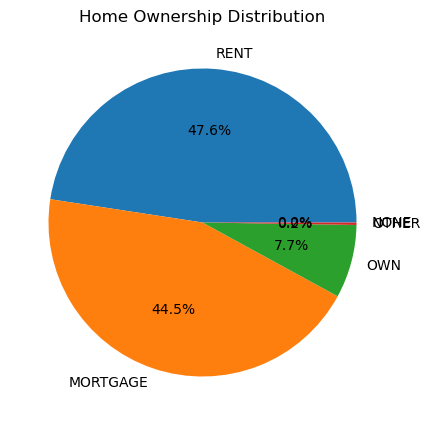

In [24]:
# plotting a pie chart for the same

home = loan_df.home_ownership.value_counts(normalize=True)
plt.figure(figsize=(5,5))
plt.pie(home, labels=['RENT','MORTGAGE','OWN','OTHER','NONE'], autopct='%1.1f%%')
plt.title('Home Ownership Distribution')
plt.show()

#### It is clear that most borrowers have a rented home (47.6%), followed by those who currently have a mortgage (44.5%).

### 2. 'annual_inc' variable

#### Indicates the borrower's self-reported annual income.

In [25]:
# checking the values of 'annual_inc' variable

loan_df.annual_inc.value_counts()

annual_inc
60000.00      1505
50000.00      1057
40000.00       876
45000.00       830
30000.00       825
75000.00       811
65000.00       803
70000.00       733
48000.00       723
80000.00       662
55000.00       653
36000.00       631
42000.00       608
90000.00       573
35000.00       517
100000.00      513
120000.00      497
85000.00       490
72000.00       488
24000.00       404
52000.00       396
54000.00       369
110000.00      316
95000.00       285
62000.00       267
25000.00       250
78000.00       248
38000.00       242
150000.00      240
32000.00       220
58000.00       219
130000.00      214
56000.00       209
96000.00       208
125000.00      207
43000.00       206
66000.00       205
105000.00      203
68000.00       199
63000.00       193
53000.00       192
84000.00       189
57000.00       188
51000.00       187
33000.00       182
37000.00       175
47000.00       168
140000.00      167
44000.00       164
38400.00       159
46000.00       155
115000.00      150
8

#### It is confusing to look at each value individually, hence, let us categorize the annual income values into 4 buckets (or bins) - <br><br> 1. 0 to 50k <br><br> 2. 50k to 1 lakh <br><br> 3. 1 lakh to 1.5 lakh, and <br><br> 4. 1.5 lakh to 2 lakhs

In [27]:
# Define the bin edges
bins = [0, 50000, 100000, 150000, 200000]

# Define the bin labels
labels = ['0-50k', '50k-1L', '1L-1.5L', '1.5L-2L']

# Create a new column with the categories
loan_df['annual_inc_buckets'] = pd.cut(loan_df['annual_inc'], bins=bins, labels=labels, right=False)

loan_df.head(10)

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,policy_code,acc_now_delinq,pub_rec_bankruptcies,annual_inc_buckets
0,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,credit_card,Computer,AZ,27.65,0,Jan-85,1,0.0,3,0,13648,83.70%,9,0.00,0.00,5863.155187,5833.84,5000.00,863.16,0.00,0.00,0.00,Jan-15,171.62,May-16,1,0,0.0,0-50k
1,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,car,bike,GA,1.00,0,Apr-99,5,0.0,3,0,1687,9.40%,4,0.00,0.00,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,Sep-13,1,0,0.0,0-50k
2,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,small_business,real estate business,IL,8.72,0,Nov-01,2,0.0,2,0,2956,98.50%,10,0.00,0.00,3005.666844,3005.67,2400.00,605.67,0.00,0.00,0.00,Jun-14,649.91,May-16,1,0,0.0,0-50k
3,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,other,personel,CA,20.00,0,Feb-96,1,35.0,10,0,5598,21%,37,0.00,0.00,12231.890000,12231.89,10000.00,2214.92,16.97,0.00,0.00,Jan-15,357.48,Apr-16,1,0,0.0,0-50k
4,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,other,Personal,OR,17.94,0,Jan-96,0,38.0,15,0,27783,53.90%,38,524.06,524.06,3513.330000,3513.33,2475.94,1037.39,0.00,0.00,0.00,May-16,67.79,May-16,1,0,0.0,50k-1L
5,1311441,5000,5000,5000.0,36 months,7.90%,156.46,A4,Veolia Transportaton,3 years,RENT,36000.0,Source Verified,Dec-11,Fully Paid,wedding,My wedding loan I promise to pay back,AZ,11.20,0,Nov-04,3,0.0,9,0,7963,28.30%,12,0.00,0.00,5632.210000,5632.21,5000.00,632.21,0.00,0.00,0.00,Jan-15,161.03,Jan-16,1,0,0.0,0-50k
6,1304742,7000,7000,7000.0,60 months,15.96%,170.08,C5,Southern Star Photography,8 years,RENT,47004.0,Not Verified,Dec-11,Fully Paid,debt_consolidation,Loan,NC,23.51,0,Jul-05,1,0.0,7,0,17726,85.60%,11,0.00,0.00,10110.840000,10110.84,6985.61,3125.23,0.00,0.00,0.00,May-16,1313.76,May-16,1,0,0.0,0-50k
7,1288686,3000,3000,3000.0,36 months,18.64%,109.43,E1,MKC Accounting,9 years,RENT,48000.0,Source Verified,Dec-11,Fully Paid,car,Car Downpayment,CA,5.35,0,Jan-07,2,0.0,4,0,8221,87.50%,4,0.00,0.00,3939.135294,3939.14,3000.00,939.14,0.00,0.00,0.00,Jan-15,111.34,Dec-14,1,0,0.0,0-50k
8,1306957,5600,5600,5600.0,60 months,21.28%,152.39,F2,NaN,4 years,OWN,40000.0,Source Verified,Dec-11,Charged Off,small_business,Expand Business & Buy Debt Portfolio,CA,5.55,0,Apr-04,2,0.0,11,0,5210,32.60%,13,0.00,0.00,646.020000,646.02,162.02,294.94,0.00,189.06,2.09,Apr-12,152.39,Aug-12,1,0,0.0,0-50k
9,1306721,5375,5375,5350.0,60 months,12.69%,121.45,B5,Starbucks,< 1 year,RENT,15000.0,Verified,Dec-11,Charged Off,other,Building my credit history.,TX,18.08,0,Sep-04,0,0.0,2,0,9279,36.50%,3,0.00,0.00,1476.190000,1469.34,673.48,533.42,0.00,269.29,2.52,Nov-12,121.45,Mar-13,1,0,0.0,0-50k


In [28]:
# now, checking the values of 'annual_inc_buckets' variable

loan_df.annual_inc_buckets.value_counts(normalize=True)*100

annual_inc_buckets
50k-1L     48.270912
0-50k      37.650286
1L-1.5L    11.302520
1.5L-2L     2.776282
Name: proportion, dtype: float64

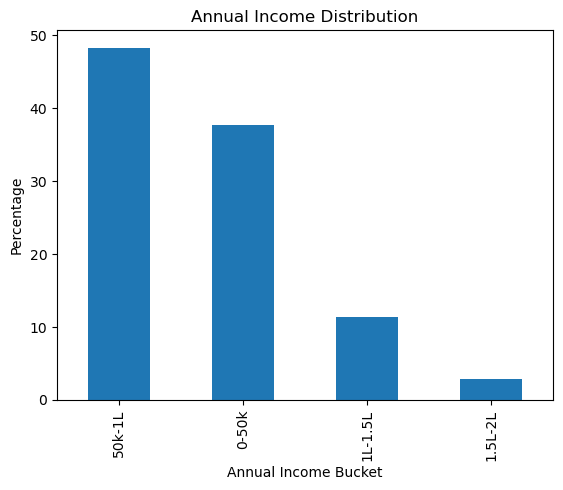

In [29]:
# plotting bar graph for the same

income = 100 * loan_df.annual_inc_buckets.value_counts(normalize=True)
income.plot.bar()
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income Bucket')
plt.ylabel('Percentage')
plt.show()

#### We can see that most borrowers fall under the 50k-1lakh annual income bucket, followed by 0-50k bucket.

### 3. 'emp_length' variable

#### Indicates the borrower's employment length in years. Generally, borrowers with high employment length, i.e., those who have been in the work force since a long time, are preferred, as they are more likely to repay the loans.

In [35]:
# calculating null value percentage for this column

100 * loan_df.emp_length.isnull().sum() / len(loan_df.index)

2.7066495455346575

#### Null value percentage is 2.7%, which can be IGNORED since it's a small number compared to the size of the dataset.

In [36]:
# understanding the values of emp_length column
loan_df.emp_length.value_counts(normalize=True) * 100

emp_length
10+ years    22.977589
< 1 year     11.860152
2 years      11.355520
3 years      10.597278
4 years       8.891879
5 years       8.493349
1 year        8.384659
6 years       5.768335
7 years       4.588272
8 years       3.827442
9 years       3.255525
Name: proportion, dtype: float64

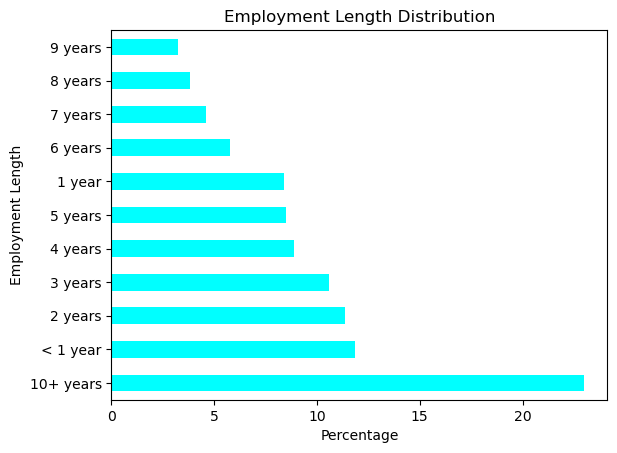

In [37]:
# visualizing its distribution using a bar graph

emplength = loan_df.emp_length.value_counts(normalize=True) * 100
emplength.plot.barh(color='cyan')
plt.title('Employment Length Distribution')
plt.ylabel('Employment Length')
plt.xlabel('Percentage')
plt.show()

#### As evident, 22% (almost 1/4th) of borrowers have 10+ years of employment length, which is a good thing.

### 4. 'term' variable

#### indicates the tenure of the loan, whether it is for 36 months (3 years), or for 60 months (5 years).

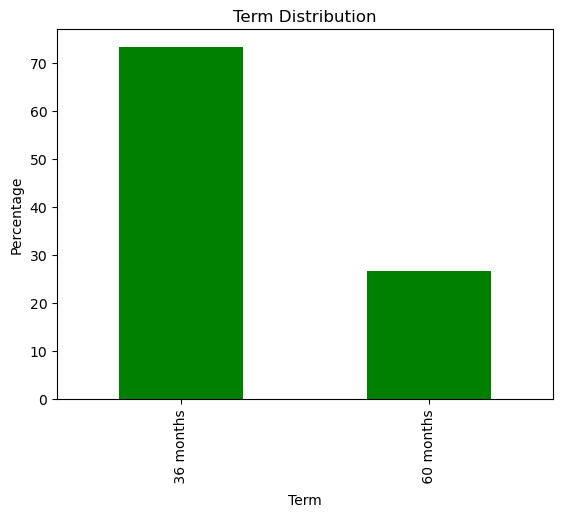

In [430]:
# plotting bar graph for 'term' to see its distribution

trm = 100 * loan_df.term.value_counts(normalize=True)
trm.plot.bar(color='green')
plt.title('Term Distribution')
plt.xlabel('Term')
plt.ylabel('Percentage')
plt.show()

In [431]:
100 * loan_df.term.value_counts(normalize=True)

term
 36 months    73.258302
 60 months    26.741698
Name: proportion, dtype: float64

#### Almost 3/4th of the loans being given are for a period of 36 months. The rest 1/4th are for 60 months.

### 5. 'inq_last_6mths' variable

#### Indicates how many loan inquiries the borrower has made in the last 6 months. 
#### Higher the value, greater the risk, since more inquiries means that the borrower is very eager to get a loan.
#### Banks should always be cautious of such credit-hungry customers, as they are the ones most likely to default.

In [437]:
# checking the distribution of this column
100 * loan_df.inq_last_6mths.value_counts(normalize=True)

inq_last_6mths
0    48.593801
1    27.622932
2    14.633532
3     7.674296
4     0.820807
5     0.367601
6     0.161140
7     0.088123
8     0.037767
Name: proportion, dtype: float64

#### We can see that around 2-3% of borrowers have made 4 or more inquiries in the last 6 months, and hence may be avoided.

### 6. 'delinq_2yrs' variable

#### Indicates the number of 30+ days delinquencies of a customer in the last 2 years. Definitely, a higher count means a risky customer.

In [447]:
loan_df.head()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,policy_code,acc_now_delinq,pub_rec_bankruptcies,annual_inc_buckets
0,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,credit_card,Computer,AZ,27.65,0,Jan-85,1,NaN,3,0,13648,83.70%,9,0.00,0.00,5863.155187,5833.84,5000.00,863.16,0.00,0.00,0.00,Jan-15,171.62,May-16,1,0,0.0,0-50k
1,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,car,bike,GA,1.00,0,Apr-99,5,NaN,3,0,1687,9.40%,4,0.00,0.00,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,Sep-13,1,0,0.0,0-50k
2,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,small_business,real estate business,IL,8.72,0,Nov-01,2,NaN,2,0,2956,98.50%,10,0.00,0.00,3005.666844,3005.67,2400.00,605.67,0.00,0.00,0.00,Jun-14,649.91,May-16,1,0,0.0,0-50k
3,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,other,personel,CA,20.00,0,Feb-96,1,35.0,10,0,5598,21%,37,0.00,0.00,12231.890000,12231.89,10000.00,2214.92,16.97,0.00,0.00,Jan-15,357.48,Apr-16,1,0,0.0,0-50k
4,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,other,Personal,OR,17.94,0,Jan-96,0,38.0,15,0,27783,53.90%,38,524.06,524.06,3513.330000,3513.33,2475.94,1037.39,0.00,0.00,0.00,May-16,67.79,May-16,1,0,0.0,50k-1L


In [470]:
# checking the distribution of values in this column
loan_df.delinq_2yrs.value_counts(normalize=True) * 100

delinq_2yrs
0     89.143188
1      8.316338
2      1.729738
3      0.553919
4      0.156104
5      0.055392
6      0.025178
7      0.010071
8      0.005036
9      0.002518
11     0.002518
Name: proportion, dtype: float64

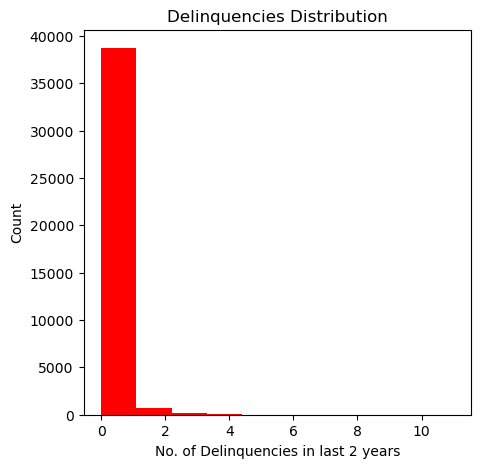

In [42]:
# plotting a histogram for it

plt.figure(figsize=[5,5])
plt.hist(loan_df.delinq_2yrs, color='red')
plt.title('Delinquencies Distribution')
plt.xlabel('No. of Delinquencies in last 2 years')
plt.ylabel('Count')
plt.show()

#### Most borrowers (89.2%) do not have any past delinquencies in the last 2 years, which is a good thing. The remaining 10.8% of borrowers can be considered cautiously.

### 7. 'verification_status' variable

#### Indicates whether the income source of the borrower is verified or not.

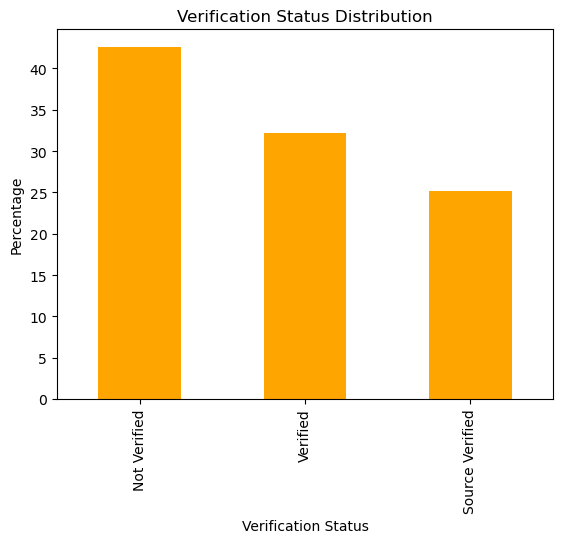

In [591]:
# checking the distribution of values in this column
vs = 100 * loan_df.verification_status.value_counts(normalize=True)

# plotting a bar graph for the same
vs.plot.bar(color='orange')
plt.title('Verification Status Distribution')
plt.xlabel('Verification Status')
plt.ylabel('Percentage')
plt.show()

#### We have more than 40% of borrowers whose income source is not verified.

### 8. 'pub_rec_bankruptcies' variable

#### Refers to the number of bankruptcy filings found in public records associated with an individual. It reflects past financial distress and those with atleast 1 such case in the past should be considered as less creditworthy.

In [477]:
# checking the distribution of values in this column
loan_df.pub_rec_bankruptcies.value_counts(normalize=True)  * 100 

pub_rec_bankruptcies
0.0    95.691953
1.0     4.290108
2.0     0.017940
Name: proportion, dtype: float64

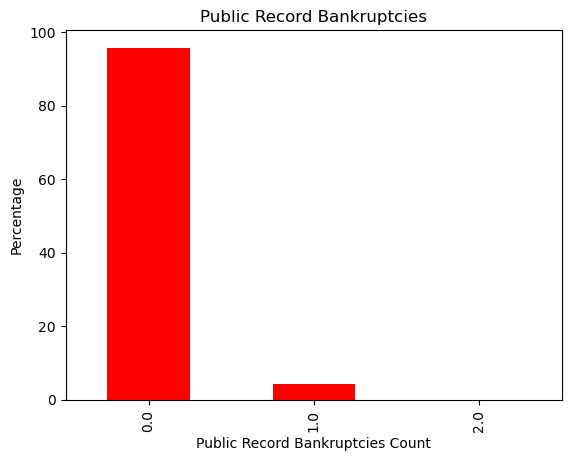

In [43]:
# plotting bar graph

prb = 100 * loan_df.pub_rec_bankruptcies.value_counts(normalize=True)
prb.plot.bar(color='red')
plt.title('Public Record Bankruptcies')
plt.xlabel('Public Record Bankruptcies Count')
plt.ylabel('Percentage')
plt.show()

#### Over 95% of borrowers do not have any public recorded bankruptcies, which is a good thing. The other 5% can be considered risky customers.

### 9. 'loan_status' variable (the target)

#### This is the target variable, which indicates whether a loan has been fully paid/current/charged off. Determining what factors affect this variable is our goal.

In [488]:
# checking the distribution of values in this column
loan_df.loan_status.value_counts(normalize=True) * 100

loan_status
Fully Paid     82.961956
Charged Off    14.167737
Current         2.870307
Name: proportion, dtype: float64

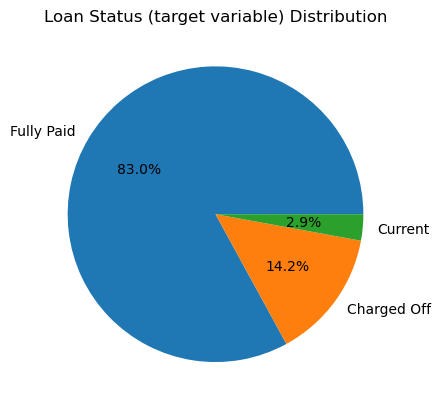

In [490]:
# plotting pie chart

ls = loan_df.loan_status.value_counts(normalize=True)
plt.pie(ls, labels=['Fully Paid','Charged Off','Current'], autopct='%1.1f%%')
plt.title('Loan Status (target variable) Distribution')
plt.show()

#### 14.2% borrowers have charged off loans, which is a loss to the company. This should be reduced.

In [492]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   member_id                39717 non-null  int64   
 1   loan_amnt                39717 non-null  int64   
 2   funded_amnt              39717 non-null  int64   
 3   funded_amnt_inv          39717 non-null  float64 
 4   term                     39717 non-null  object  
 5   int_rate                 39717 non-null  object  
 6   installment              39717 non-null  float64 
 7   sub_grade                39717 non-null  object  
 8   emp_title                37258 non-null  object  
 9   emp_length               38642 non-null  object  
 10  home_ownership           39717 non-null  object  
 11  annual_inc               39717 non-null  float64 
 12  verification_status      39717 non-null  object  
 13  issue_d                  39717 non-null  object  
 14  loan_s

## Bivariate Analysis

#### Let us understand how each numeric variable in the dataset effects the 'loan_status' variable. 
#### Performing bivariate analysis of each numeric variable against 'loan_status'.

### 1. 'annual_inc' vs 'loan_status' (Numeric-Categorical analysis)

In [508]:
# counting the number of each 'loan_status' category across each 'annual_inc_bucket'
ann_inc_1 = loan_df.groupby(['annual_inc_buckets', 'loan_status'])[['loan_status']].size().reset_index(name='count')
ann_inc_1

,annual_inc_buckets,loan_status,count
0,0-50k,Charged Off,2449
1,0-50k,Current,327
2,0-50k,Fully Paid,11911
3,50k-1L,Charged Off,2534
4,50k-1L,Current,592
5,50k-1L,Fully Paid,15704
6,1L-1.5L,Charged Off,455
7,1L-1.5L,Current,139
8,1L-1.5L,Fully Paid,3815
9,1.5L-2L,Charged Off,118


#### Let us represent count as a percentage of whole, to get a better picture.

In [498]:
# Total counts per each annual_inc_bucket
ann_inc_2 = loan_df.groupby('annual_inc_buckets').size().reset_index(name='total_count')

# Merging counts with total counts
merged_ai = pd.merge(ann_inc_1, ann_inc_2, on='annual_inc_buckets')

# Calculating percentage
merged_ai['percentage'] = (merged_ai['count'] / merged_ai['total_count']) * 100

merged_ai[['annual_inc_buckets','loan_status','percentage']]

,annual_inc_buckets,loan_status,percentage
0,0-50k,Charged Off,16.674610
1,0-50k,Current,2.226459
2,0-50k,Fully Paid,81.098931
3,50k-1L,Charged Off,13.457249
4,50k-1L,Current,3.143919
5,50k-1L,Fully Paid,83.398832
6,1L-1.5L,Charged Off,10.319800
7,1L-1.5L,Current,3.152642
8,1L-1.5L,Fully Paid,86.527557
9,1.5L-2L,Charged Off,10.895660


#### The above shows the percentage of each loan status for each annual income bucket.

In [509]:
# filtering only charged_off loans from the above, since we want to know their percentage

charged_off_ai = merged_ai[merged_ai['loan_status'] == 'Charged Off']

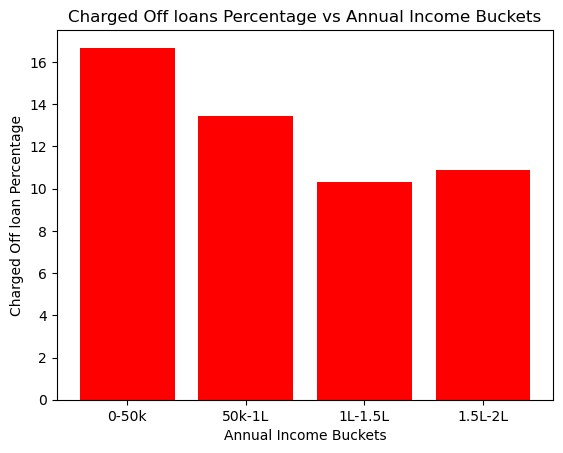

In [510]:
# plotting bar graph of percentage of charged_off loans across various annual income buckets

plt.bar(charged_off_ai['annual_inc_buckets'], charged_off_ai['percentage'], color='red')
plt.title('Charged Off loans Percentage vs Annual Income Buckets')
plt.xlabel('Annual Income Buckets')
plt.ylabel('Charged Off loan Percentage')
plt.show()

#### We can observe that 'Charged Off' loans are highest for borrowers belonging to 0-50k annual income range.

### 2. 'home_ownership' vs 'loan_status' (Categorical-Categorical analysis)

#### Following the same above-mentioned approach for all other bivariate analyses.

In [543]:
# finding count of each loan_status for each home_ownership category
home1 = loan_df.groupby(['home_ownership', 'loan_status'])[['loan_status']].size().reset_index(name='count')

In [544]:
# Total counts per annual_inc_buckets
home2 = loan_df.groupby('home_ownership').size().reset_index(name='total_count')

# Merge counts with total counts
merged_home = pd.merge(home1, home2, on='home_ownership')

# Calculate percentage
merged_home['percentage'] = (merged_home['count'] / merged_home['total_count']) * 100

merged_home[['home_ownership','loan_status','percentage']]

,home_ownership,loan_status,percentage
0,MORTGAGE,Charged Off,13.177417
1,MORTGAGE,Current,3.612889
2,MORTGAGE,Fully Paid,83.209695
3,NONE,Fully Paid,100.000000
4,OTHER,Charged Off,18.367347
5,OTHER,Fully Paid,81.632653
6,OWN,Charged Off,14.486593
7,OWN,Current,2.714192
8,OWN,Fully Paid,82.799215
9,RENT,Charged Off,15.021959


In [545]:
# filtering only charged_off loans
charged_off_home = merged_home[merged_home['loan_status'] == 'Charged Off']

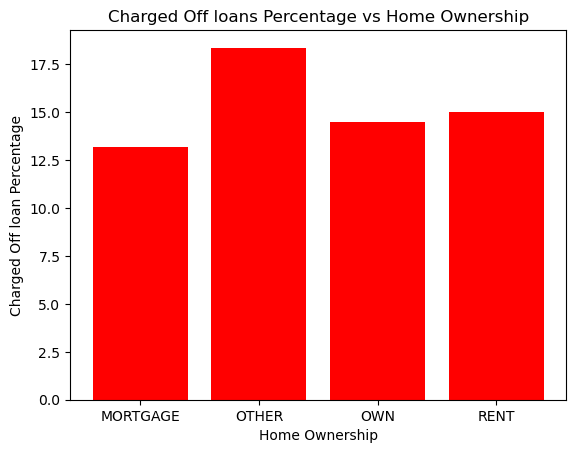

In [546]:
# plotting bar graph 

plt.bar(charged_off_home['home_ownership'], charged_off_home['percentage'], color='red')
plt.title('Charged Off loans Percentage vs Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Charged Off loan Percentage')
plt.show()

#### We can observe that charged off loan percentage is least for borrowers who either own a house, or currently have a mortgage on them, as was presumed by us. Hence, these borrowers should be more preferred.

### 3. 'dti' vs 'delinq_2yrs' (Numeric-Numeric analysis)

#### DTI (Debt-to-Income) ratio is the borrower's debts vs income value. High DTI ratio means that the person spends more than what they earn, while low ratio indicates less debts and more income. Borrowers with low DTI ratios are preferred.

#### Let us create buckets for DTI ratio, which is ranging from 0 to 30 here, as we did for annual income. This is to simplify our analysis. 

In [547]:
# Define the bin edges
bins = [0, 10, 20, 30]

# Define the bin labels
labels = ['0-10', '10-20', '20-30']

# Create a new column with the categorized data
loan_df['dti_buckets'] = pd.cut(loan_df['dti'], bins=bins, labels=labels, right=False)

loan_df.head(10)

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,policy_code,acc_now_delinq,pub_rec_bankruptcies,annual_inc_buckets,dti_buckets
0,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,credit_card,Computer,AZ,27.65,0,Jan-85,1,NaN,3,0,13648,83.70%,9,0.00,0.00,5863.155187,5833.84,5000.00,863.16,0.00,0.00,0.00,Jan-15,171.62,May-16,1,0,0.0,0-50k,20-30
1,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,car,bike,GA,1.00,0,Apr-99,5,NaN,3,0,1687,9.40%,4,0.00,0.00,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,Sep-13,1,0,0.0,0-50k,0-10
2,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,small_business,real estate business,IL,8.72,0,Nov-01,2,NaN,2,0,2956,98.50%,10,0.00,0.00,3005.666844,3005.67,2400.00,605.67,0.00,0.00,0.00,Jun-14,649.91,May-16,1,0,0.0,0-50k,0-10
3,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,other,personel,CA,20.00,0,Feb-96,1,35.0,10,0,5598,21%,37,0.00,0.00,12231.890000,12231.89,10000.00,2214.92,16.97,0.00,0.00,Jan-15,357.48,Apr-16,1,0,0.0,0-50k,20-30
4,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,other,Personal,OR,17.94,0,Jan-96,0,38.0,15,0,27783,53.90%,38,524.06,524.06,3513.330000,3513.33,2475.94,1037.39,0.00,0.00,0.00,May-16,67.79,May-16,1,0,0.0,50k-1L,10-20
5,1311441,5000,5000,5000.0,36 months,7.90%,156.46,A4,Veolia Transportaton,3 years,RENT,36000.0,Source Verified,Dec-11,Fully Paid,wedding,My wedding loan I promise to pay back,AZ,11.20,0,Nov-04,3,NaN,9,0,7963,28.30%,12,0.00,0.00,5632.210000,5632.21,5000.00,632.21,0.00,0.00,0.00,Jan-15,161.03,Jan-16,1,0,0.0,0-50k,10-20
6,1304742,7000,7000,7000.0,60 months,15.96%,170.08,C5,Southern Star Photography,8 years,RENT,47004.0,Not Verified,Dec-11,Fully Paid,debt_consolidation,Loan,NC,23.51,0,Jul-05,1,NaN,7,0,17726,85.60%,11,0.00,0.00,10110.840000,10110.84,6985.61,3125.23,0.00,0.00,0.00,May-16,1313.76,May-16,1,0,0.0,0-50k,20-30
7,1288686,3000,3000,3000.0,36 months,18.64%,109.43,E1,MKC Accounting,9 years,RENT,48000.0,Source Verified,Dec-11,Fully Paid,car,Car Downpayment,CA,5.35,0,Jan-07,2,NaN,4,0,8221,87.50%,4,0.00,0.00,3939.135294,3939.14,3000.00,939.14,0.00,0.00,0.00,Jan-15,111.34,Dec-14,1,0,0.0,0-50k,0-10
8,1306957,5600,5600,5600.0,60 months,21.28%,152.39,F2,NaN,4 years,OWN,40000.0,Source Verified,Dec-11,Charged Off,small_business,Expand Business & Buy Debt Portfolio,CA,5.55,0,Apr-04,2,NaN,11,0,5210,32.60%,13,0.00,0.00,646.020000,646.02,162.02,294.94,0.00,189.06,2.09,Apr-12,152.39,Aug-12,1,0,0.0,0-50k,0-10
9,1306721,5375,5375,5350.0,60 months,12.69%,121.45,B5,Starbucks,< 1 year,RENT,15000.0,Verified,Dec-11,Charged Off,other,Building my credit history.,TX,18.08,0,Sep-04,0,NaN,2,0,9279,36.50%,3,0.00,0.00,1476.190000,1469.34,673.48,533.42,0.00,269.29,2.52,Nov-12,121.45,Mar-13,1,0,0.0,0-50k,10-20


In [548]:
# checking average no. of delinquencies in the last 2 years, per each dti ratio bucket

grouped_dti = loan_df.groupby('dti_buckets')[['delinq_2yrs']].mean()
grouped_dti

,delinq_2yrs
dti_buckets,
0-10,0.163687
10-20,0.145571
20-30,0.118712


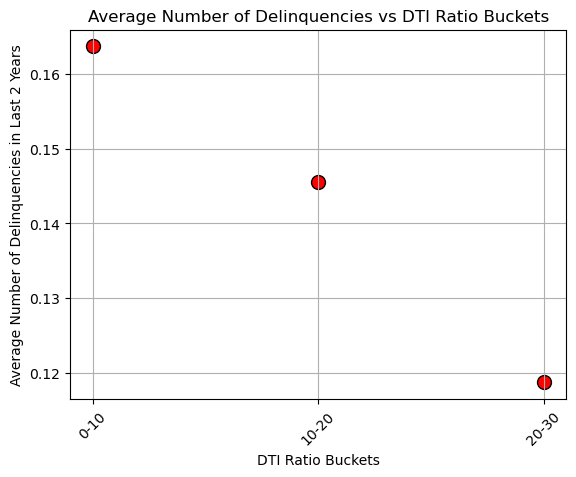

In [549]:
# plotting the same as a scatterplot

plt.scatter(grouped_dti.index, grouped_dti.delinq_2yrs, color='red', s=100, edgecolor='black')
plt.xlabel('DTI Ratio Buckets')
plt.ylabel('Average Number of Delinquencies in Last 2 Years')
plt.title('Average Number of Delinquencies vs DTI Ratio Buckets')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#### There is negative correlation betweeen these two variables i.e., as DTI ratio increases, average count of delinquencies decreases. 

### 4. 'annual_inc' vs 'delinq_2yrs' (Numeric-Numeric analysis)

In [550]:
# calculating average count of delinquencies in the last 2 years, per each annual income bucket

grouped_ai = loan_df.groupby('annual_inc_buckets')[['delinq_2yrs']].mean()
grouped_ai

,delinq_2yrs
annual_inc_buckets,
0-50k,0.128753
50k-1L,0.150929
1L-1.5L,0.173736
1.5L-2L,0.161588


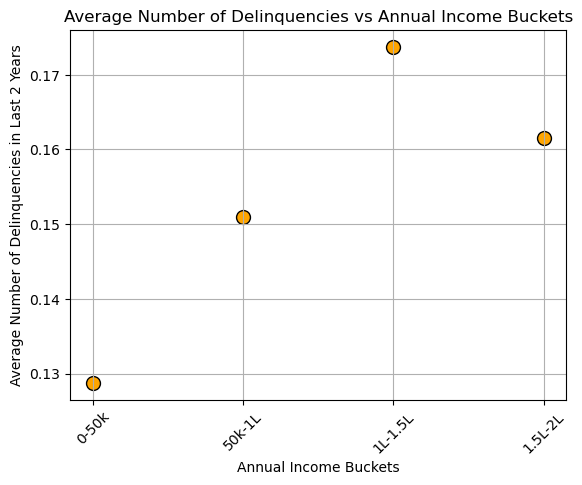

In [551]:
# plotting the same as a scatterplot

plt.scatter(grouped_ai.index, grouped_ai.delinq_2yrs, color='orange', s=100, edgecolor='black')

plt.xlabel('Annual Income Buckets')
plt.ylabel('Average Number of Delinquencies in Last 2 Years')
plt.title('Average Number of Delinquencies vs Annual Income Buckets')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

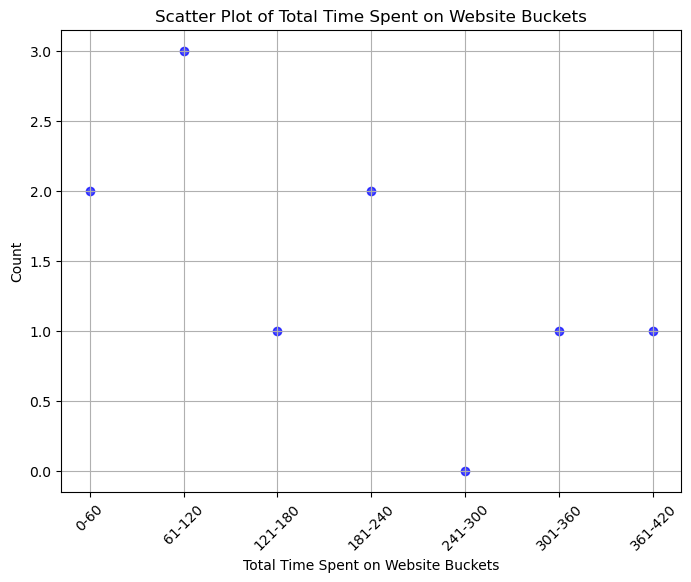

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data creation
data = {
    'Total Time Spent on Website': [30, 45, 60, 90, 120, 200, 300, 400, 180, 100],
}
leads = pd.DataFrame(data)

# Define bins and labels for Total Time Spent on Website
bins = [0, 60, 120, 180, 240, 300, 360, 420]
labels = ['0-60', '61-120', '121-180', '181-240', '241-300', '301-360', '361-420']

# Create a new column with the buckets
leads['Total Time Spent on Website_buckets'] = pd.cut(leads['Total Time Spent on Website'], bins=bins, labels=labels, right=False)

# Count occurrences of each bucket
bucket_counts = leads['Total Time Spent on Website_buckets'].value_counts().sort_index()

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(bucket_counts.index, bucket_counts.values, color='blue', marker='o', alpha=0.7)

# Add titles and labels
plt.title('Scatter Plot of Total Time Spent on Website Buckets')
plt.xlabel('Total Time Spent on Website Buckets')
plt.ylabel('Count')

# Show grid for better readability
plt.grid(True)

# Show the plot
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.show()


#### Borrowers with higher annual income have slightly higher average no. of delinquecies in the last 2 years.

### 5. 'emp_length' vs 'loan_status' (Numeric-Categorical analysis)

#### Let's see the affect employment length has on loan status.

In [552]:
# counting each loan_status value for each emp_length

el1 = loan_df.groupby(['emp_length', 'loan_status'])[['loan_status']].size().reset_index(name='count')

In [554]:
# calculating it as a % of the whole

el2 = loan_df.groupby(['emp_length']).size().reset_index(name='total_count')

merged_el = pd.merge(el1, el2, on='emp_length')

# Calculate percentage
merged_el['percentage'] = (merged_el['count'] / merged_el['total_count']) * 100

In [557]:
# filtering only charged off loans

final_el_df = merged_el[ merged_el.loan_status == 'Charged Off' ]
final_el_df.sort_values(by='percentage', ascending=False, inplace=True)
final_el_df[['emp_length','loan_status','percentage']]

C:\Users\sindh\AppData\Local\Temp\ipykernel_33168\678301373.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_el_df.sort_values(by='percentage', ascending=False, inplace=True)


,emp_length,loan_status,percentage
3,10+ years,Charged Off,14.990427
21,7 years,Charged Off,14.833615
0,1 year,Charged Off,14.074074
15,5 years,Charged Off,13.954906
30,< 1 year,Charged Off,13.942832
18,6 years,Charged Off,13.772992
24,8 years,Charged Off,13.725490
9,3 years,Charged Off,13.553114
12,4 years,Charged Off,13.445867
6,2 years,Charged Off,12.921604


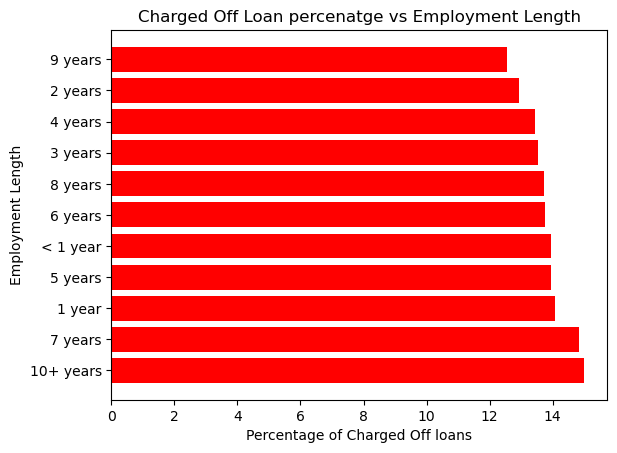

In [558]:
# plotting bar graph for the same

plt.barh(final_el_df.emp_length, final_el_df.percentage, color='red')
plt.title('Charged Off Loan percenatge vs Employment Length')
plt.ylabel('Employment Length')
plt.xlabel('Percentage of Charged Off loans')
plt.show()

#### From the above visualization, there seems to be not much correlation between these two variables.

### 6. 'dti' vs 'loan_status' (Numeric-Categorical analysis)

In [559]:
# finding count of each loan_status category for each dti_bucket

dti_1 = loan_df.groupby(['dti_buckets', 'loan_status'])['loan_status'].size().reset_index(name='count')

In [567]:
# expressing it as a percentage of whole

dti_2 = loan_df.groupby(['dti_buckets']).size().reset_index(name='total_count')

merged_dti = pd.merge(dti_1, dti_2, on='dti_buckets')

# Calculate percentage
merged_dti['percentage'] = (merged_dti['count'] / merged_dti['total_count']) * 100

final_dti = merged_dti[ merged_dti.loan_status.isin(['Charged Off','Fully Paid']) ]

final_dti[['dti_buckets','loan_status','percentage']]

,dti_buckets,loan_status,percentage
0,0-10,Charged Off,12.316316
2,0-10,Fully Paid,85.434025
3,10-20,Charged Off,14.699226
5,10-20,Fully Paid,82.390401
6,20-30,Charged Off,16.076657
8,20-30,Fully Paid,80.063881


In [586]:
# filtering only fully paid loan percentages

fully_paid_dti = final_dti[final_dti.loan_status == 'Fully Paid'].percentage

In [587]:
# filtering only charged off loan percentages

charged_off_dti = final_dti[final_dti.loan_status == 'Charged Off'].percentage

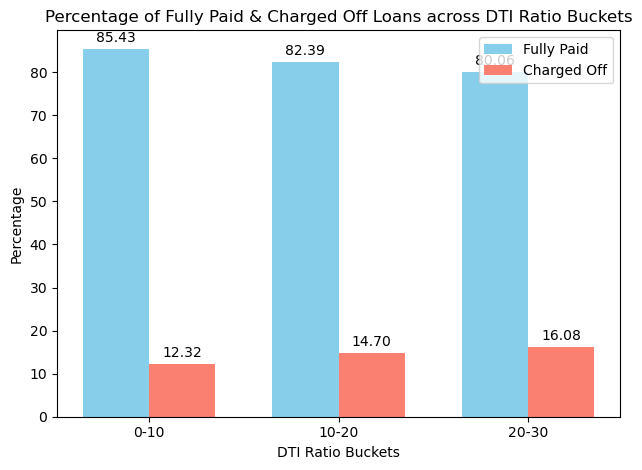

In [588]:
# plotting grouped bar graph, with percentages of both fully paid & charged off loans across each DTI ratio bucket

labels = ['0-10', '10-20', '20-30']

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, fully_paid_dti, width, color='skyblue', label='Fully Paid')
rects2 = ax.bar(x + width/2, charged_off_dti, width, color='salmon', label='Charged Off')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('DTI Ratio Buckets')
ax.set_ylabel('Percentage')
ax.set_title('Percentage of Fully Paid & Charged Off Loans across DTI Ratio Buckets')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# for annotating the bars with their respective values
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.show()

#### We can see that percentage of charged off loans increases with increase in DTI ratio.

### 7. 'term' vs 'loan_status' (Categorical-Categorical analysis)

#### Do loans with shorter term have higher charge off, or those with longer term? Let's check.

In [45]:
# finding count of each loan_status category across terms

t1 = loan_df.groupby(['term','loan_status'])[['loan_status']].size().reset_index(name='count')

In [46]:
# expressing it as a percentage of whole

t2 = loan_df.groupby(['term']).size().reset_index(name='total_count')

merged_term = pd.merge(t1, t2, on='term')

# Calculate percentage
merged_term['percentage'] = (merged_term['count'] / merged_term['total_count']) * 100

# filtering out only fully paid & charged off loans
final_term = merged_term[ merged_term.loan_status.isin(['Charged Off','Fully Paid']) ]

# displaying
final_term[['term','loan_status','percentage']]

,term,loan_status,percentage
0,36 months,Charged Off,11.090872
1,36 months,Fully Paid,88.909128
2,60 months,Charged Off,22.596742
4,60 months,Fully Paid,66.669805


#### We see that longer term loans (i.e., 60 months) have a significantly higher charge off rate. Let's plot the same in a graph now.

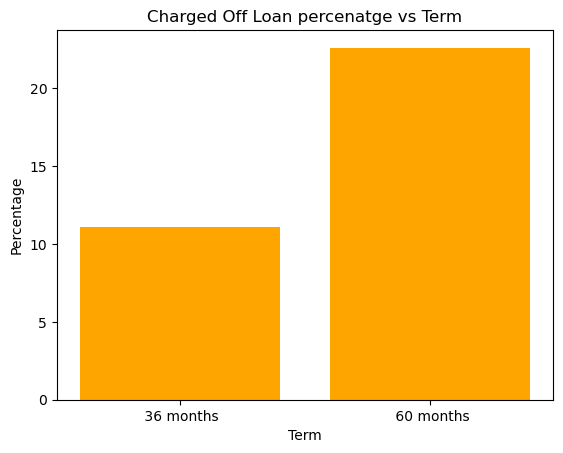

In [47]:
# plotting bar graph for the same

plt.bar(final_term[final_term.loan_status == 'Charged Off'].term, final_term[final_term.loan_status == 'Charged Off'].percentage, 
        color='orange')
plt.title('Charged Off Loan percenatge vs Term')
plt.ylabel('Percentage')
plt.xlabel('Term')

plt.show()

#### As evident, loans with term of 60 months have a SIGNIFICANTLY HIGHER charge off rate than those with 36 months!

### 8. 'inq_last_6mths ' vs 'loan_status' (Numeric-Categorical analysis)

In [615]:
# finding count of each loan_status category across no. of inquiries in the last 6 months

inq1 = loan_df.groupby(['inq_last_6mths','loan_status'])[['loan_status']].size().reset_index(name='count')

In [619]:
# expressing it as a percentage of whole

inq2 = loan_df.groupby(['inq_last_6mths']).size().reset_index(name='total_count')

merged_inq = pd.merge(inq1, inq2, on='inq_last_6mths')

# Calculate percentage
merged_inq['percentage'] = (merged_inq['count'] / merged_inq['total_count']) * 100

# filtering only charged off loans
final_inq = merged_inq[ merged_inq.loan_status == 'Charged Off' ]

# soring values based on percentage column, in ascending order
final_inq.sort_values(by='percentage', ascending=True, inplace=True)

# displaying
final_inq[['inq_last_6mths','loan_status','percentage']]

C:\Users\sindh\AppData\Local\Temp\ipykernel_33168\1427160431.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_inq.sort_values(by='percentage', ascending=True, inplace=True)


,inq_last_6mths,loan_status,percentage
0,0,Charged Off,11.813472
3,1,Charged Off,15.285753
12,4,Charged Off,15.644172
6,2,Charged Off,16.225052
15,5,Charged Off,19.178082
24,8,Charged Off,20.000000
9,3,Charged Off,20.308399
18,6,Charged Off,25.000000
21,7,Charged Off,28.571429


#### We can see that there is not much correlation between more no. of inquiries and higher charge off of loans in this dataset.

### 9. 'verification_status ' vs 'loan_status' (Categorical-Categorical analysis)

In [622]:
# finding count of each loan_status category across verification_status

vs1 = loan_df.groupby(['verification_status','loan_status'])[['loan_status']].size().reset_index(name='count')

In [623]:
# expressing it as a percentage of whole

vs2 = loan_df.groupby(['verification_status']).size().reset_index(name='total_count')

merged_vs = pd.merge(vs1, vs2, on='verification_status')

# Calculate percentage
merged_vs['percentage'] = (merged_vs['count'] / merged_vs['total_count']) * 100

# filtering only charged off loans
final_vs = merged_vs[ merged_vs.loan_status == 'Charged Off' ]

# soring values based on percentage column, in ascending order
final_vs.sort_values(by='percentage', ascending=True, inplace=True)

# displaying
final_vs[['verification_status','loan_status','percentage']]

C:\Users\sindh\AppData\Local\Temp\ipykernel_33168\2973864905.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_vs.sort_values(by='percentage', ascending=True, inplace=True)


,verification_status,loan_status,percentage
0,Not Verified,Charged Off,12.658826
3,Source Verified,Charged Off,14.358666
6,Verified,Charged Off,16.012179


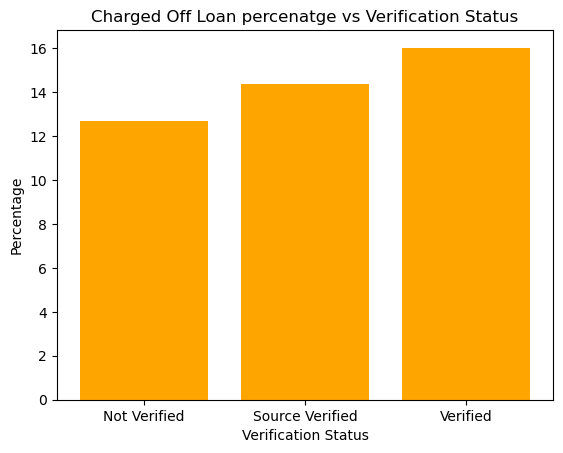

In [624]:
# plotting bar graph for the same

plt.bar(final_vs.verification_status, final_vs.percentage, 
        color='orange')
plt.title('Charged Off Loan percenatge vs Verification Status')
plt.ylabel('Percentage')
plt.xlabel('Verification Status')

plt.show()

#### Again, there is not much correlation between verification status & charged off loan percentage.

### This finishes our analyses. We will summarize all the findings in a PDF document along with the visualizations.